In [1]:
import numpy as np
def read_cebaf(filename):
    data = np.load(filename)
    nentries = int(data.shape[0]/3)
    heat = data[0:nentries]
    trip = data[nentries:2*nentries]
    alpha = data[2*nentries:3*nentries] 
    return heat,trip,alpha

In [3]:
import os
import matplotlib.pyplot as plt
from pymoo.indicators.hv import HV

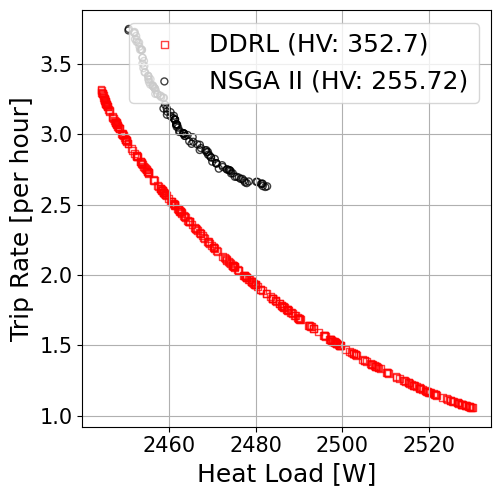

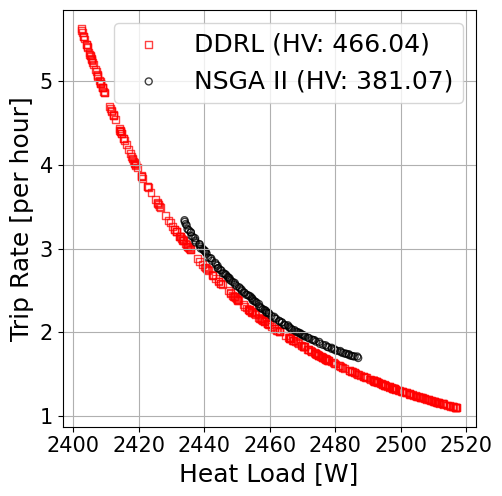

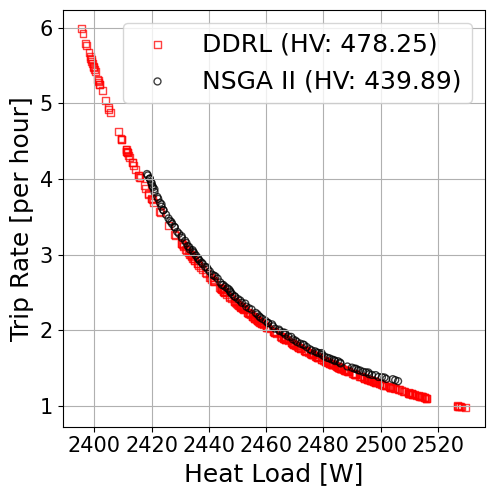

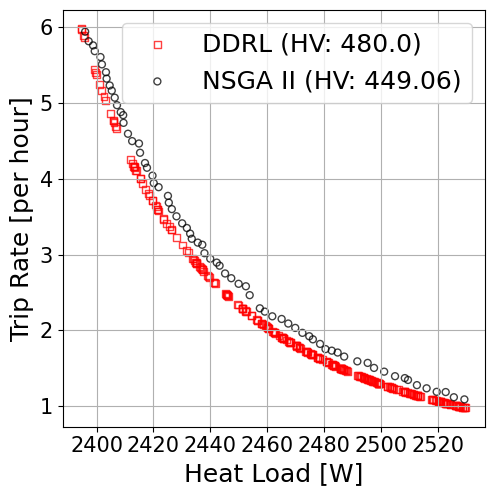

In [24]:
# ga_result_loc = "../drivers/results/CEBAF_Paper/NSGA_8D/"
# ga_filename_prefix = "1L10_TEST8_nsga_II_results_"
# ddrl_result_loc = "../drivers/results/CEBAF_Paper/index0_agent_MO-KerasMB-v0_env_PACES-MO-CEBAF-8D-VEC-TF_date_20240828-152554/"
# ref = [22.2, 0.04]

ga_result_loc = "../drivers/results/CEBAF_Paper/NSGA_North/"
ga_filename_prefix = "North_nsga_II_results_"
ddrl_result_loc = "../drivers/results/CEBAF_Paper/index0_agent_MO-KerasMB-v0_env_PACES-MO-CEBAF-N-VEC-TF_date_20240828-191706/"
ref = [2530, 6]
ind = HV(ref_point=ref)

for i in [1000, 5000, 15000, 100000]:
    ga_results = np.load(os.path.join(ga_result_loc, ga_filename_prefix+str(i).zfill(6)+".npy"))
    ga_heat, ga_trip = ga_results[:, 0], ga_results[:, 1]
    good_indices = np.where((ga_heat <= ref[0]) & (ga_trip <= ref[1]))[0]
    ga_heat, ga_trip = ga_heat[good_indices], ga_trip[good_indices]
    ga_results = np.stack([ga_heat, ga_trip], axis=1)
    ga_hv = np.round(ind(ga_results), 2)
    
    mb_heat, mb_trip, mb_alpha = read_cebaf(os.path.join(ddrl_result_loc, 'inference_results_steps'+str(i)+'.npy'))
    good_indices = np.where((mb_heat <= ref[0]) & (mb_trip <= ref[1]))[0]
    mb_heat, mb_trip, mb_alpha = mb_heat[good_indices], mb_trip[good_indices], mb_alpha[good_indices]
    rl_results = np.stack([mb_heat, mb_trip], axis=1)
    rl_hv = np.round(ind(rl_results), 2)
    
    
    fig, ax = plt.subplots(figsize=(5, 5))
    plt.scatter(mb_heat, mb_trip, marker='s', s=25, edgecolors='red', facecolor="none", alpha=0.75, label="DDRL (HV: "+str(rl_hv)+")")
    plt.scatter(ga_heat, ga_trip, marker='o', s=25, edgecolors='black', facecolor="none", alpha=0.75, label="NSGA II (HV: "+str(ga_hv)+")")
    # plt.scatter(ga_data[:,0], ga_data[:,1], marker='*', s=25, facecolors='none', alpha=0.75, edgecolors='blue', label="NSGA II")
    plt.legend(fontsize=18)
    plt.grid()
    plt.xlabel('Heat Load [W]', fontsize=18)
    plt.ylabel('Trip Rate [per hour]', fontsize=18);
    # plt.colorbar()
    plt.tight_layout()
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.savefig('cebaf_mo_evolution_'+str(i)+'.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [58]:
data = np.load('1L10_TEST8_nsga_II_results.npy')
print(data.shape)

(128, 2)


(190,)
(190,)
(190,)


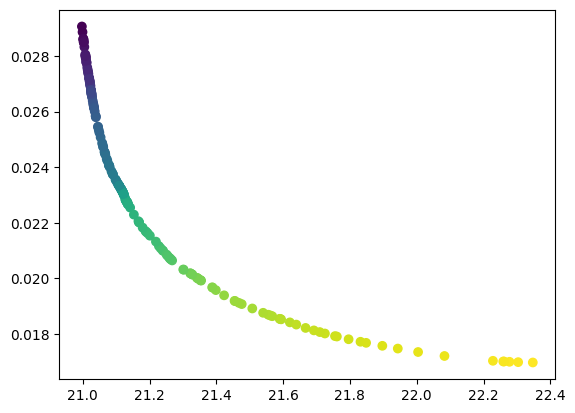

In [38]:
import numpy as np
data = np.load('../drivers/results'
               +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash4cc092e_results_20240731-145258'
               +'/inference_results_steps250000.npy')
nentries = int(data.shape[0]/3)
heat = data[0:nentries]
trip = data[nentries:2*nentries]
alpha = data[2*nentries:3*nentries]
print(heat.shape)
print(trip.shape)
print(alpha.shape)
# print(data[0:nentries])
# data = data.reshape(nentries,-1)
# print(data.shape)
# print(data[:,0])
import matplotlib.pyplot as plt
plt.scatter(heat, trip, c=alpha, marker='o')